# S6E9: FT-Transformer (Feature Tokenizer Transformer)
Treating Tabular Data exactly like an LLM treats text. This pushes both numerical and categorical features into a massive Self-Attention space.
If you find this powerful, please upvote!

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gc

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

## -- Machine Learning --
from sklearn.calibration import CalibrationDisplay
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.preprocessing import QuantileTransformer, LabelEncoder, KBinsDiscretizer, TargetEncoder

import warnings
warnings.filterwarnings('ignore')
pd.set_option("display.max_columns", 500)

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# 1. Load Data
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/test.csv')
submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e9/sample_submission.csv')
orig = pd.read_csv('/kaggle/input/datasets/itzzomkar/ev-adoption-behavior-and-range-anxiety/EV_Adoption_and_Range_Anxiety_Dataset.csv')

orig = orig.drop(columns=['Buyer_ID'], errors='ignore')
orig = orig.dropna()
orig['id'] = -1

TARGET = 'Will_Buy_EV'
orig[TARGET]  = orig[TARGET].map({'Yes': 1, 'No': 0})
train[TARGET] = train[TARGET].map({'Yes': 1, 'No': 0})

train = pd.concat([train, orig], axis=0).reset_index(drop=True)
print(f"Combined Train size: {train.shape}")

Combined Train size: (678131, 15)


In [3]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
combined = pd.concat([train, test], ignore_index=True)

cat_cols = combined.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = [c for c in FEATURES if c not in cat_cols + ['id', TARGET]]

digits_cols = []
cols_select = ["Annual_Income_USD", "Daily_Commute_km", "Age"]

for col in cols_select:
    scaled = np.rint(combined[col] * 10**4).astype("int64")
    for k in range(-4, 4):
        dig_col = f"{col}_digit{k}"
        combined[dig_col] = (scaled // 10**(k + 4) % 10).astype('int8')
        digits_cols.append(dig_col)

train = combined.iloc[:len(train)][FEATURES+[TARGET]+digits_cols]
test  = combined.iloc[len(train):len(train)+len(test)][FEATURES+digits_cols]
# orig  = combined.iloc[len(train)+len(test):]

# Check nunique, and find which ones are < 2
unique_counts = train[digits_cols].nunique()
drop_cols = unique_counts[unique_counts < 2].index.tolist()

train = train.drop(columns=drop_cols)
test  = test.drop(columns=drop_cols)

# update digit cols for keep
digits_cols = [item for item in set(digits_cols) if item not in set(drop_cols)]

train

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Daily_Commute_km_digit2,Age_digit0,Age_digit1
0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,0.0,7,8,8,2,4,3,2,0,6,6
1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,0.0,0,0,0,0,0,5,0,0,8,3
2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,1.0,9,8,3,4,8,6,3,0,6,2
3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,0.0,0,8,5,3,7,3,2,0,6,6
4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,0.0,8,9,8,7,8,0,5,0,4,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678126,50,61279.0,71.4,1,8,3,3.0,Male,Urban,Sedan,No,Yes,Medium,0.0,9,7,2,1,4,1,7,0,0,5
678127,34,108208.0,48.0,2,9,7,5.0,Male,Urban,Hatchback,No,No,Low,0.0,8,0,2,8,0,8,4,0,4,3
678128,60,97743.0,9.0,2,10,3,5.0,Female,Urban,Sedan,No,Yes,Low,0.0,3,4,7,7,0,9,0,0,0,6
678129,31,103628.0,81.8,2,10,10,1.0,Female,Urban,SUV,Yes,Yes,Low,0.0,8,2,6,3,8,1,8,0,1,3


In [4]:
# 2. Feature Engineering
def feature_engineering(df1):
    df = df1.copy()
    df['Subsidy_Available_Num'] = (df['Subsidy_Available'] == 'Yes').astype(int)
    df['Home_Charging_Num'] = (df['Home_Charging_Possible'] == 'Yes').astype(int)
    
    anxiety_map = {'Low': 0, 'Medium': 1, 'High': 2}
    if 'Range_Anxiety_Level' in df.columns:
        df['Anxiety_Score'] = df['Range_Anxiety_Level'].map(anxiety_map)
        
    df['Sub_x_Env'] = df['Subsidy_Available_Num'] * df['Environmental_Concern_Level']
    df['Sub_x_Home'] = df['Subsidy_Available_Num'] * df['Home_Charging_Num']
    df['Income_Per_Age'] = df['Annual_Income_USD'] / (df['Age'] + 1)

    return df

train_fe = feature_engineering(train)
test_fe  = feature_engineering(test)

# 3. Preprocessing
cat_cols = ['Gender', 'City_Type', 'Current_Car_Type', 'Subsidy_Available',
            'Home_Charging_Possible', 'Range_Anxiety_Level'] + digits_cols
num_cols = ['Age', 'Annual_Income_USD', 'Daily_Commute_km', 'Number_of_Cars_Owned', 
            'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work', 
            'Environmental_Concern_Level', 'Sub_x_Env', 'Sub_x_Home', 'Income_Per_Age', 'Anxiety_Score']

for c in num_cols:
    train_fe[c] = train_fe[c].fillna(train_fe[c].median())
    test_fe[c] = test_fe[c].fillna(train_fe[c].median())

cat_dims = []
for c in cat_cols:
    le = LabelEncoder()
    train_fe[c] = le.fit_transform(train_fe[c].astype(str))
    test_fe[c] = le.transform(test_fe[c].astype(str))
    cat_dims.append(len(le.classes_))

# qt = QuantileTransformer(output_distribution='normal', random_state=42)
# train_fe[num_cols] = qt.fit_transform(train_fe[num_cols])
# test_fe[num_cols] = qt.transform(test_fe[num_cols])

X_cat = train_fe[cat_cols].values
X_num = train_fe[num_cols].values
y = train_fe['Will_Buy_EV'].values

X_test_cat = test_fe[cat_cols].values
X_test_num = test_fe[num_cols].values

train_fe

,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,Annual_Income_USD_digit0,Annual_Income_USD_digit1,Annual_Income_USD_digit2,Annual_Income_USD_digit3,Daily_Commute_km_digit-1,Daily_Commute_km_digit0,Daily_Commute_km_digit1,Daily_Commute_km_digit2,Age_digit0,Age_digit1,Subsidy_Available_Num,Home_Charging_Num,Anxiety_Score,Sub_x_Env,Sub_x_Home,Income_Per_Age
0,66,92887.0,23.4,2,3,7,1.0,1,1,2,1,0,1,0.0,7,8,8,2,4,3,2,0,6,4,0,1,0,0.0,0,1386.373134
1,38,30000.0,5.0,1,2,2,4.0,1,0,1,1,0,1,0.0,0,0,0,0,0,5,0,0,8,1,0,1,0,0.0,0,769.230769
2,26,94389.0,36.8,1,8,15,5.0,0,2,2,0,1,1,1.0,9,8,3,4,8,6,3,0,6,0,1,0,0,5.0,0,3495.888889
3,66,73580.0,23.7,2,6,9,3.0,1,1,0,1,0,1,0.0,0,8,5,3,7,3,2,0,6,4,0,1,0,0.0,0,1098.208955
4,54,57898.0,50.8,1,2,3,3.0,1,1,0,1,0,1,0.0,8,9,8,7,8,0,5,0,4,3,0,1,0,0.0,0,1052.690909
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
678126,50,61279.0,71.4,1,8,3,3.0,1,2,2,0,1,2,0.0,9,7,2,1,4,1,7,0,0,3,1,0,1,3.0,0,1201.549020
678127,34,108208.0,48.0,2,9,7,5.0,1,2,0,0,0,1,0.0,8,0,2,8,0,8,4,0,4,1,0,0,0,0.0,0,3091.657143
678128,60,97743.0,9.0,2,10,3,5.0,0,2,2,0,1,1,0.0,3,4,7,7,0,9,0,0,0,4,1,0,0,5.0,0,1602.344262
678129,31,103628.0,81.8,2,10,10,1.0,0,2,1,1,1,1,0.0,8,2,6,3,8,1,8,0,1,1,1,1,0,1.0,1,3238.375000


In [5]:
# 4. PyTorch Dataset & FT-Transformer Architecture
class TabularDataset(Dataset):
    def __init__(self, x_cat, x_num, y=None):
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
        
    def __len__(self):
        return len(self.x_num)
        
    def __getitem__(self, idx):
        if self.y is not None:
            return self.x_cat[idx], self.x_num[idx], self.y[idx]
        return self.x_cat[idx], self.x_num[idx]

class FTTransformer(nn.Module):
    def __init__(self, cat_dims, num_features, d_token=32, n_blocks=3, n_heads=4, ff_dropout=0.1):
        super().__init__()
        self.cat_dims = cat_dims
        self.num_features = num_features
        
        # Tokenize Categoricals
        self.cat_embeddings = nn.ModuleList([
            nn.Embedding(num_classes, d_token) for num_classes in cat_dims
        ])
        
        # Tokenize Numericals (each numerical feature gets multiplied by a learned weight vector to become d_token dim)
        self.num_embeddings = nn.Parameter(torch.randn(num_features, d_token))
        self.num_biases = nn.Parameter(torch.randn(num_features, d_token))
        
        # [CLS] Token (like in BERT, used for final classification)
        self.cls_token = nn.Parameter(torch.randn(1, 1, d_token))
        
        # Standard Transformer Encoder Blocks
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_token, 
            nhead=n_heads, 
            dim_feedforward=d_token * 2, 
            dropout=ff_dropout, 
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_blocks)
        
        # Final prediction head
        self.head = nn.Sequential(
            nn.LayerNorm(d_token),
            nn.Linear(d_token, d_token // 2),
            nn.ReLU(),
            nn.Linear(d_token // 2, 1)
        )

    def forward(self, x_cat, x_num):
        batch_size = x_num.size(0)
        
        # 1. Process Categoricals
        cat_embs = []
        for i, emb in enumerate(self.cat_embeddings):
            cat_embs.append(emb(x_cat[:, i]).unsqueeze(1)) # Shape: (batch_size, 1, d_token)
            
        # 2. Process Numericals
        # x_num is (batch_size, num_features)
        # self.num_embeddings is (num_features, d_token)
        num_embs = x_num.unsqueeze(-1) * self.num_embeddings.unsqueeze(0) + self.num_biases.unsqueeze(0)
        
        # 3. Combine
        if len(cat_embs) > 0:
            cat_embs = torch.cat(cat_embs, dim=1)
            x = torch.cat([cat_embs, num_embs], dim=1) # Shape: (batch_size, num_cat + num_num, d_token)
        else:
            x = num_embs
            
        # 4. Add CLS Token
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1) # Shape: (batch_size, 1 + num_cat + num_num, d_token)
        
        # 5. Transformer Pass
        x = self.transformer(x)
        
        # 6. Extract CLS token output and classify
        cls_out = x[:, 0, :]
        return self.head(cls_out).squeeze(1)


In [6]:
%%time

# Training Loop (GPU Accelerated)
MODEL_NAME = 'torch_FTT30'
FOLDS = 10

print(f"\n🚀 Training {MODEL_NAME} with {FOLDS } Folds...", end=" | ")
skf = StratifiedKFold(n_splits=FOLDS, shuffle=True, random_state=42)
oof_preds  = np.zeros(len(train))
test_preds = np.zeros(len(test))

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on Device: {device}")

BATCH_SIZE = 1024
EPOCHS = 30

for fold, (train_idx, val_idx) in enumerate(skf.split(X_num, y)):
    print(f"\n--- FOLD {fold+1}/{FOLDS} ---")
    X_train_num, X_valid_num = X_num[train_idx], X_num[val_idx]
    X_train_cat, X_valid_cat = X_cat[train_idx], X_cat[val_idx]
    y_train, y_valid = y[train_idx], y[val_idx]

    X_test_c, X_test_n = X_test_cat.copy(), X_test_num.copy()

    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    X_train_num = qt.fit_transform(X_train_num)
    X_valid_num = qt.transform(X_valid_num)
    X_test_n = qt.transform(X_test_n)

    train_dataset = TabularDataset(X_train_cat, X_train_num, y_train)
    val_dataset   = TabularDataset(X_valid_cat, X_valid_num, y_valid)
    test_dataset  = TabularDataset(X_test_c, X_test_n)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = FTTransformer(cat_dims, len(num_cols), d_token=32, n_blocks=3, n_heads=4, ff_dropout=0.05).to(device)
    criterion = nn.BCEWithLogitsLoss()

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.0)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    best_val_auc = 0

    for epoch in range(EPOCHS):
        model.train()
        train_loss = 0
        for b_cat, b_num, b_y in train_loader:
            b_cat, b_num, b_y = b_cat.to(device), b_num.to(device), b_y.to(device)

            optimizer.zero_grad()
            logits = model(b_cat, b_num)
            loss = criterion(logits, b_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        scheduler.step()

        model.eval()
        val_preds = []
        val_targets = []
        with torch.no_grad():
            for b_cat, b_num, b_y in val_loader:
                b_cat, b_num = b_cat.to(device), b_num.to(device)
                logits = model(b_cat, b_num)
                val_preds.extend(torch.sigmoid(logits).cpu().numpy())
                val_targets.extend(b_y.cpu().numpy())

        val_auc = roc_auc_score(val_targets, val_preds)
        print(f"Epoch {epoch+1}/{EPOCHS} | AUC: {val_auc:.6f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), f"ft_fold_{fold}.pth")
            oof_preds[val_idx] = val_preds

    model.load_state_dict(torch.load(f"ft_fold_{fold}.pth", weights_only=True))
    model.eval()
    fold_test_preds = []
    with torch.no_grad():
        for b_cat, b_num in test_loader:
            b_cat, b_num = b_cat.to(device), b_num.to(device)
            logits = model(b_cat, b_num)
            fold_test_preds.extend(torch.sigmoid(logits).cpu().numpy())

    test_preds += np.array(fold_test_preds) / FOLDS

oof_auc = np.round(roc_auc_score(y, oof_preds), 6)

print("\n" + "="*45)
print(f"🏆   {MODEL_NAME} OOF AUC: {oof_auc}")
print("="*45)


🚀 Training torch_FTT30 with 10 Folds... | Training on Device: cuda

--- FOLD 1/10 ---
Epoch 1/30 | AUC: 0.938175
Epoch 2/30 | AUC: 0.938915
Epoch 3/30 | AUC: 0.938507
Epoch 4/30 | AUC: 0.939443
Epoch 5/30 | AUC: 0.939540
Epoch 6/30 | AUC: 0.939554
Epoch 7/30 | AUC: 0.939825
Epoch 8/30 | AUC: 0.939884
Epoch 9/30 | AUC: 0.940223
Epoch 10/30 | AUC: 0.940385
Epoch 11/30 | AUC: 0.940574
Epoch 12/30 | AUC: 0.940954
Epoch 13/30 | AUC: 0.940830
Epoch 14/30 | AUC: 0.940948
Epoch 15/30 | AUC: 0.940947
Epoch 16/30 | AUC: 0.941071
Epoch 17/30 | AUC: 0.941074
Epoch 18/30 | AUC: 0.941268
Epoch 19/30 | AUC: 0.941255
Epoch 20/30 | AUC: 0.941442
Epoch 21/30 | AUC: 0.941350
Epoch 22/30 | AUC: 0.941247
Epoch 23/30 | AUC: 0.941453
Epoch 24/30 | AUC: 0.941446
Epoch 25/30 | AUC: 0.941391
Epoch 26/30 | AUC: 0.941371
Epoch 27/30 | AUC: 0.941443
Epoch 28/30 | AUC: 0.941444
Epoch 29/30 | AUC: 0.941445
Epoch 30/30 | AUC: 0.941443

--- FOLD 2/10 ---
Epoch 1/30 | AUC: 0.936801
Epoch 2/30 | AUC: 0.937504
Epoch 3/3

In [7]:
print("="*40)
print(f"🏆   {MODEL_NAME} OOF AUC: {oof_auc}")
print("="*40)

# MODEL_NAME = f"{MODEL_NAME}_a"

# Save OOF Predictions (for ensembling meta-model)
# oof_df = pd.DataFrame({'id': train['id'], 'OOF_Pred': oof_preds})
# oof_df.to_csv(f'oof_{MODEL_NAME}.csv', index=False)
np.save(f"oof_{MODEL_NAME}_{oof_auc}.npy", oof_preds)
print(f"💾 Saved 'oof_{MODEL_NAME}_{oof_auc}.npy'")

# Save Raw Test Predictions (for ensembling)
# test_df = pd.DataFrame({'id': test['id'], TARGET: test_preds})
# test_df.to_csv(f'test_{MODEL_NAME}.csv', index=False)
np.save(f"test_{MODEL_NAME}_{oof_auc}.npy", test_preds)
print(f"💾 Saved 'test_{MODEL_NAME}_{oof_auc}.npy'")

# Save Kaggle Submission (Averaged Test Predictions)
submission['Will_Buy_EV'] = test_preds
submission.to_csv(f'submission_{MODEL_NAME}_{oof_auc}.csv', index=False)
print(f"💾 Saved 'submission_{MODEL_NAME}_{oof_auc}.csv'")

submission

🏆   torch_FTT30 OOF AUC: 0.941041
💾 Saved 'oof_torch_FTT30_0.941041.npy'
💾 Saved 'test_torch_FTT30_0.941041.npy'
💾 Saved 'submission_torch_FTT30_0.941041.csv'


,id,Will_Buy_EV
0,668665,0.008756
1,668666,0.018421
2,668667,0.003856
3,668668,0.002913
4,668669,0.018481
...,...,...
286566,955231,0.000128
286567,955232,0.266192
286568,955233,0.003975
286569,955234,0.000190


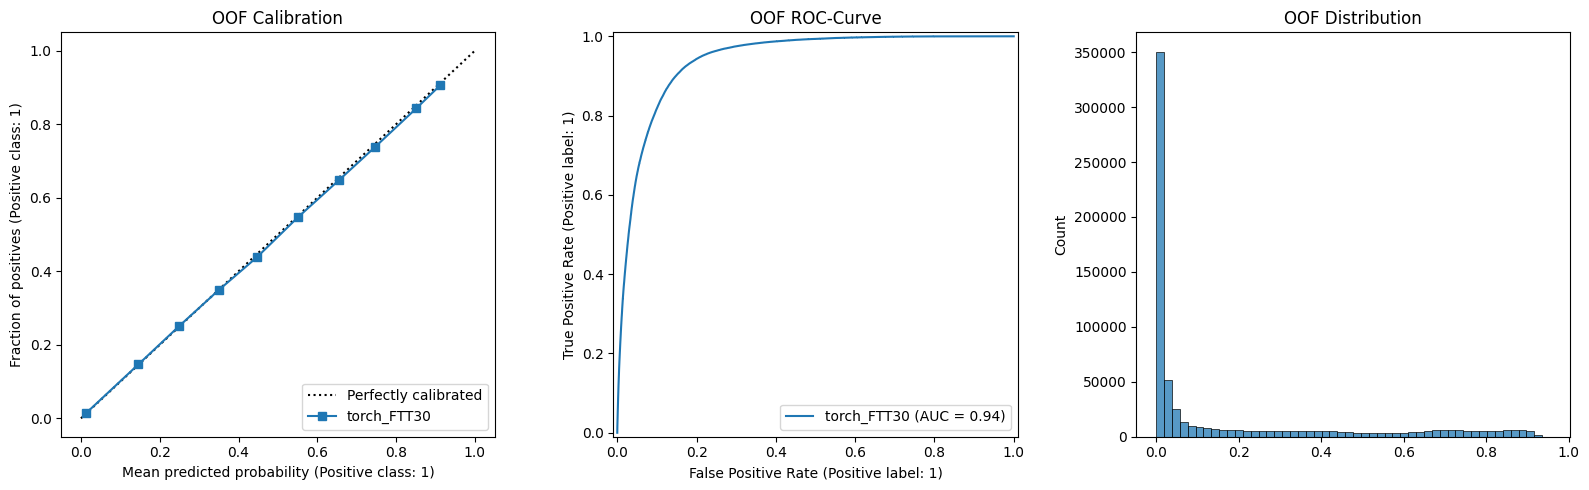

In [8]:
## -- Plot oof distributions --
_, axs = plt.subplots(1, 3, figsize=(16, 5)) 
CalibrationDisplay.from_predictions(train_fe[TARGET], oof_preds, n_bins=10, name=MODEL_NAME, ax=axs[0])
axs[0].set_title(f"OOF Calibration")

RocCurveDisplay.from_predictions(train_fe[TARGET], oof_preds, name=MODEL_NAME, ax=axs[1])
axs[1].set_title(f"OOF ROC-Curve")

sns.histplot(oof_preds, ax=axs[2], bins=50)
axs[2].set_title(f"OOF Distribution")

plt.tight_layout()
plt.show()

In [9]:
# !rm -r /kaggle/working/